In [2]:
import pickle 
import pickle 
import os
import xarray as xr
import pandas as pd
import numpy as np
import sys
import os
sys.path.append('..')
from model.RBFNetwork import RBFNetwork


def load_rbf_params(type="train"):
    with open(f'{type}/time_to_coeff.pkl', 'rb') as f:
        time_to_coeff = pickle.load(f)

    with open(f'{type}/time_to_metric.pkl', 'rb') as f:
        time_to_metric = pickle.load(f)

    with open(f'{type}/int_to_data.pkl', 'rb') as f:
        int_to_data = pickle.load(f)

    with open(f'rbf.pkl', 'rb') as f:
        rbf = pickle.load(f)

    return time_to_coeff, time_to_metric, int_to_data, rbf

train_time_to_coeff, train_time_to_metrics, int_to_data_train, rbf = load_rbf_params(type="train")
test_time_to_coeff, test_time_to_metrics, int_to_data_test, rbf_ = load_rbf_params(type="test")
val_time_to_coeff, val_time_to_metrics, int_to_data_val, rbf_ = load_rbf_params(type="val")

train_df = pd.read_csv("train/dataframe.csv")
test_df = pd.read_csv("test/dataframe.csv")
val_df = pd.read_csv("val/dataframe.csv")

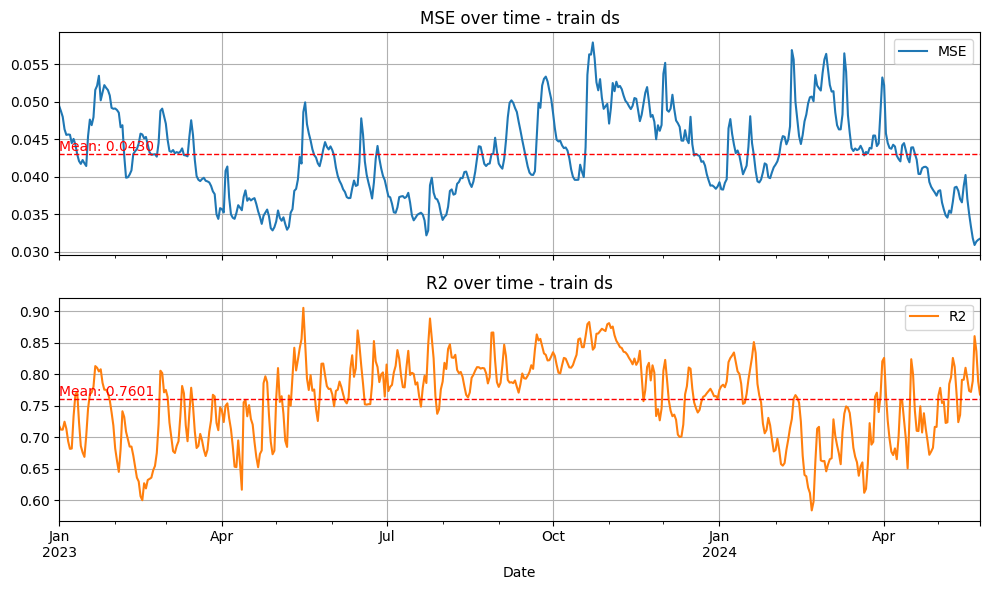

In [3]:
import matplotlib.pyplot as plt

train_time_to_metrics_df = pd.DataFrame.from_dict(train_time_to_metrics, orient='index', columns=['MSE', 'R2'])
train_time_to_metrics_df.index.name = 'Date'

axes = train_time_to_metrics_df.plot(
    y=['MSE', 'R2'],
    subplots=True,
    figsize=(10,6),
    grid=True,
    title=['MSE over time - train ds', 'R2 over time - train ds']
)

for col, ax in zip(['MSE', 'R2'], axes):
    mean_val = train_time_to_metrics_df[col].mean()
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
    ax.text(train_time_to_metrics_df.index[0], mean_val, f'Mean: {mean_val:.4f}', color='red', va='bottom')

plt.tight_layout()
plt.show()


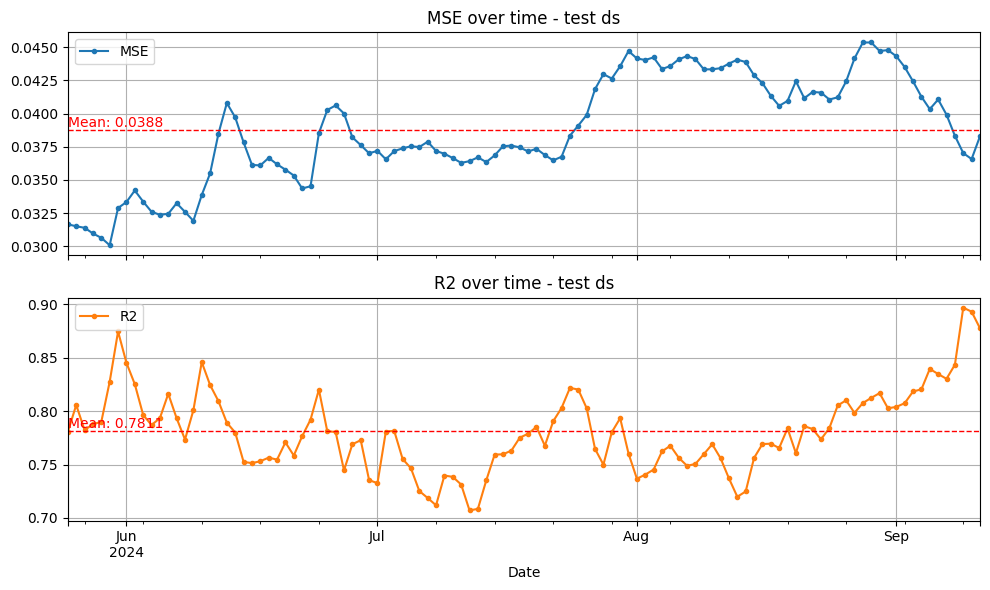

In [4]:
import matplotlib.pyplot as plt

test_time_to_metrics_df = pd.DataFrame.from_dict(test_time_to_metrics, orient='index', columns=['MSE', 'R2'])
test_time_to_metrics_df.index.name = 'Date'

axes = test_time_to_metrics_df.plot(
    y=['MSE', 'R2'],
    subplots=True,
    figsize=(10,6),
    grid=True,
    title=['MSE over time - test ds', 'R2 over time - test ds'],
    marker = '.'
)

for col, ax in zip(['MSE', 'R2'], axes):
    mean_val = test_time_to_metrics_df[col].mean()
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
    ax.text(test_time_to_metrics_df.index[0], mean_val, f'Mean: {mean_val:.4f}', color='red', va='bottom')

plt.tight_layout()
plt.show()


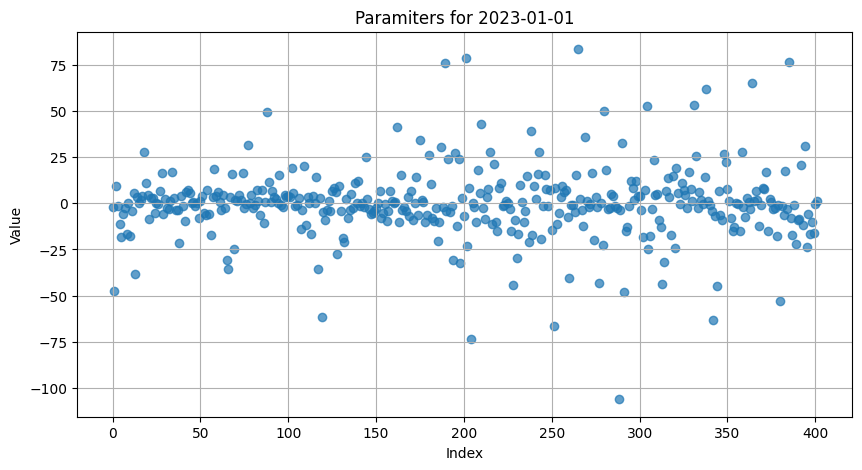

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

arr = list(train_time_to_coeff.values())[0]  # extract the array
date = list(train_time_to_coeff.keys())[0]   # extract the timestamp

plt.figure(figsize=(10,5))
plt.scatter(range(len(arr)), arr, alpha=0.7)
plt.title(f'Paramiters for {date.date()}')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Bar Plot of all Values \n arr.max()=189.57 \narr.min()=-214.38')

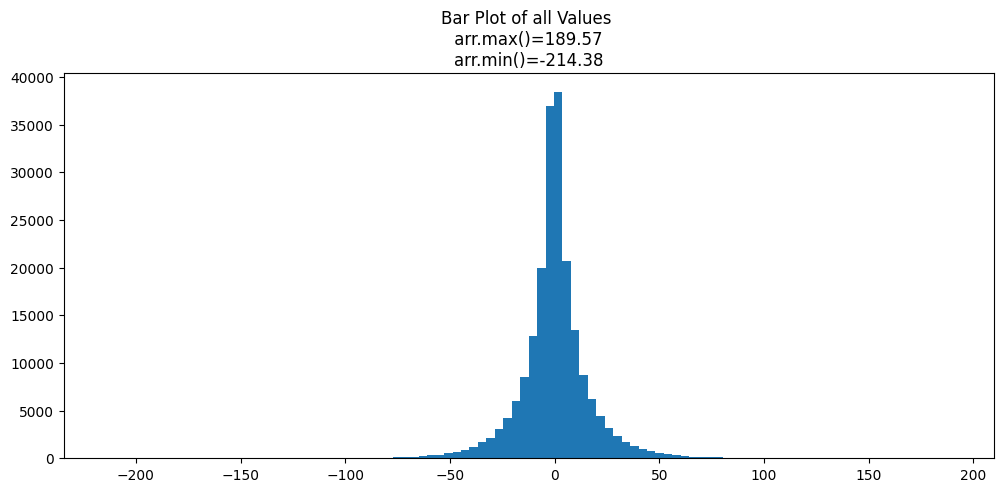

In [6]:
arr = np.array(list(train_time_to_coeff.values())).flatten()

plt.figure(figsize=(12,5))
plt.hist(arr, bins=100)
plt.title(f'Bar Plot of all Values \n {arr.max()=:.2f} \n{arr.min()=:.2f}')

